ORIGINAL DATASET
Shape: (21263, 84)

After Cleaning:
Shape: (21262, 84)

Number of Features: 81
Number of Samples: 21262

Constant Features Removed: 0

DATA SPLIT
Training Set   : 14883 samples
Validation Set : 3189 samples
Test Set       : 3190 samples

Highly Correlated Features Removed: 23
Final Number of Features: 58

Training SVR Model...
Training Completed!

VALIDATION RESULTS
Validation MAE      : 7.4268
Validation MSE      : 164.0105
Validation RMSE     : 12.8067
Validation R² Score : 0.8602

FINAL TEST RESULTS
Test MAE       : 7.6145
Test MSE       : 178.6351
Test RMSE      : 13.3654
Test R² Score  : 0.8457


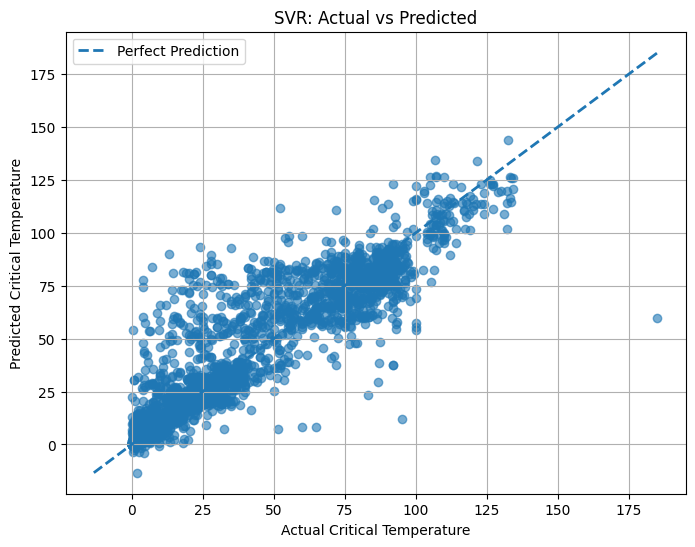

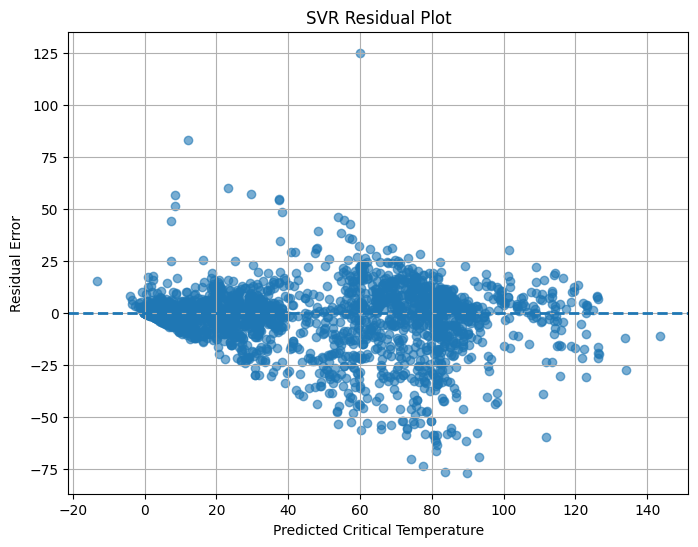

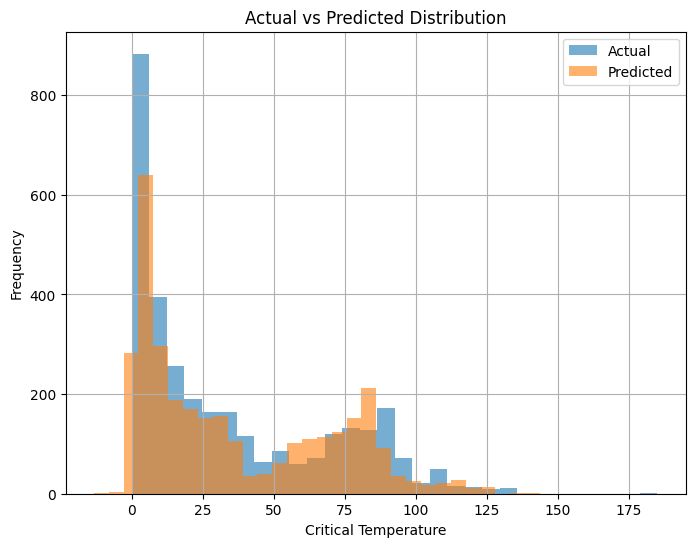

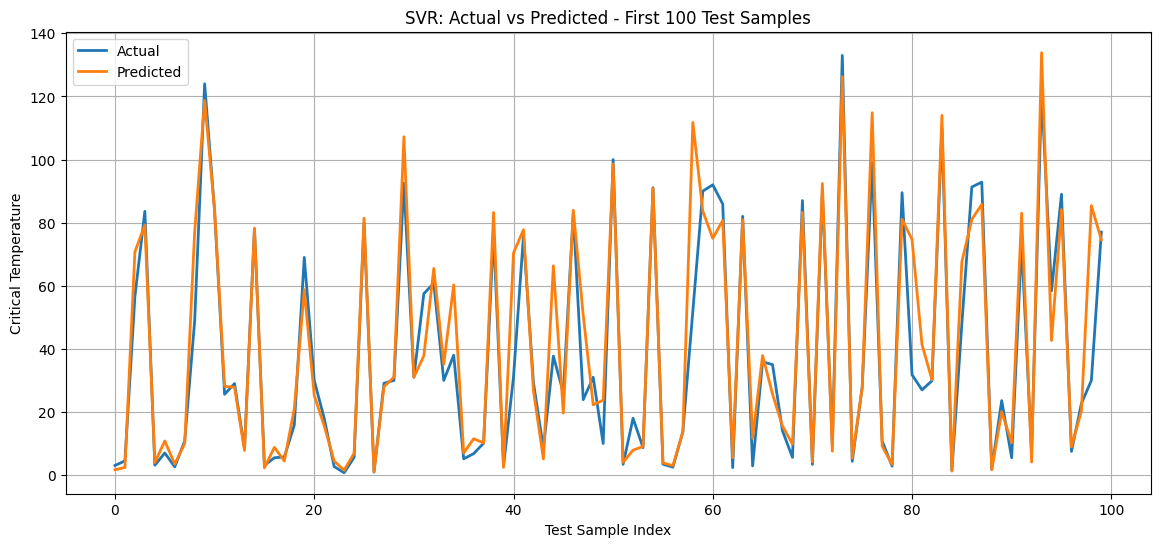


FIRST 10 TEST PREDICTIONS:
   Actual   Predicted  Absolute_Error   Residual
0    3.04    1.703269        1.336731   1.336731
1    4.50    2.413451        2.086549   2.086549
2   56.60   70.762592       14.162592 -14.162592
3   83.60   79.283060        4.316940   4.316940
4    3.12    3.969656        0.849656  -0.849656
5    7.00   10.804613        3.804613  -3.804613
6    2.61    3.464383        0.854383  -0.854383
7   10.80   10.042332        0.757668   0.757668
8   48.90   77.226580       28.326580 -28.326580
9  124.00  118.734290        5.265710   5.265710

Predictions saved as: svr_test_predictions.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("train .csv")

print("=" * 60)
print("ORIGINAL DATASET")
print("=" * 60)
print("Shape:", df.shape)


# ============================================================
# 2. BASIC DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates()

# Replace infinity values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Remove rows where target is missing
df = df.dropna(subset=["critical_temp"])

print("\nAfter Cleaning:")
print("Shape:", df.shape)


# ============================================================
# 3. FEATURE AND TARGET SELECTION
# ============================================================

# Target
y = df["critical_temp"]

# Remove target and text columns
X = df.drop(
    columns=[
        "critical_temp",
        "formula",
        "rawMaterial"
    ],
    errors="ignore"
)

# Keep only numerical columns
X = X.select_dtypes(include=np.number)

print("\nNumber of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])


# ============================================================
# 4. REMOVE CONSTANT FEATURES
# ============================================================

constant_columns = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

X = X.drop(columns=constant_columns)

print("\nConstant Features Removed:", len(constant_columns))


# ============================================================
# 5. SPLIT DATA
#    70% TRAIN
#    15% VALIDATION
#    15% TEST
# ============================================================

# First: 70% Train and 30% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)

print(f"Training Set   : {len(X_train)} samples")
print(f"Validation Set : {len(X_val)} samples")
print(f"Test Set       : {len(X_test)} samples")


# ============================================================
# 6. OUTLIER HANDLING
#    Calculate bounds ONLY from training data
# ============================================================

for col in X_train.columns:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply training bounds to all datasets
    X_train.loc[:, col] = X_train[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_val.loc[:, col] = X_val[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test.loc[:, col] = X_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )


# ============================================================
# 7. REMOVE HIGHLY CORRELATED FEATURES
#    Based ONLY on training data
# ============================================================

correlation_matrix = X_train.corr().abs()

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_columns = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

X_train = X_train.drop(columns=high_corr_columns)
X_val = X_val.drop(columns=high_corr_columns)
X_test = X_test.drop(columns=high_corr_columns)

print("\nHighly Correlated Features Removed:", len(high_corr_columns))
print("Final Number of Features:", X_train.shape[1])


# ============================================================
# 8. PREPROCESSING + FIXED SVR MODEL
# ============================================================

svr_model = Pipeline([

    # Fill missing feature values
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    # Remove any zero-variance features
    (
        "variance_threshold",
        VarianceThreshold(threshold=0)
    ),

    # Reduce skewness
    (
        "power_transform",
        PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )
    ),

    # Standardize features
    (
        "scaler",
        StandardScaler()
    ),

    # Fixed SVR model
    (
        "svr",
        SVR(
            kernel="rbf",
            C=100,
            epsilon=0.1,
            gamma="scale"
        )
    )
])


# ============================================================
# 9. TRAIN MODEL USING ONLY TRAINING DATA
# ============================================================

print("\nTraining SVR Model...")

svr_model.fit(X_train, y_train)

print("Training Completed!")


# ============================================================
# 10. VALIDATION RESULTS
# ============================================================

y_val_pred = svr_model.predict(X_val)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("\n" + "=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(f"Validation MAE      : {val_mae:.4f}")
print(f"Validation MSE      : {val_mse:.4f}")
print(f"Validation RMSE     : {val_rmse:.4f}")
print(f"Validation R² Score : {val_r2:.4f}")


# ============================================================
# 11. TEST RESULTS
# ============================================================

y_pred = svr_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test MAE       : {test_mae:.4f}")
print(f"Test MSE       : {test_mse:.4f}")
print(f"Test RMSE      : {test_rmse:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")

print("=" * 60)


# ============================================================
# 12. PLOT 1 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("SVR: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 13. PLOT 2 - RESIDUAL PLOT
# ============================================================

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Critical Temperature")
plt.ylabel("Residual Error")
plt.title("SVR Residual Plot")

plt.grid(True)

plt.show()


# ============================================================
# 14. PLOT 3 - ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    y_test,
    bins=30,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    y_pred,
    bins=30,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel("Critical Temperature")
plt.ylabel("Frequency")
plt.title("Actual vs Predicted Distribution")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 15. PLOT 4 - FIRST 100 TEST SAMPLES
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:100],
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred[:100],
    label="Predicted",
    linewidth=2
)

plt.xlabel("Test Sample Index")
plt.ylabel("Critical Temperature")

plt.title("SVR: Actual vs Predicted - First 100 Test Samples")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 16. SAVE PREDICTIONS
# ============================================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Absolute_Error": np.abs(y_test.values - y_pred),
    "Residual": y_test.values - y_pred
})

print("\nFIRST 10 TEST PREDICTIONS:")
print(results.head(10))

results.to_csv(
    "svr_test_predictions.csv",
    index=False
)

print("\nPredictions saved as: svr_test_predictions.csv")